In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib


In [2]:
df = pd.read_csv("../EDA/dataset/student_mental_health_nlp/dataset.csv")
df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


<Axes: ylabel='status'>

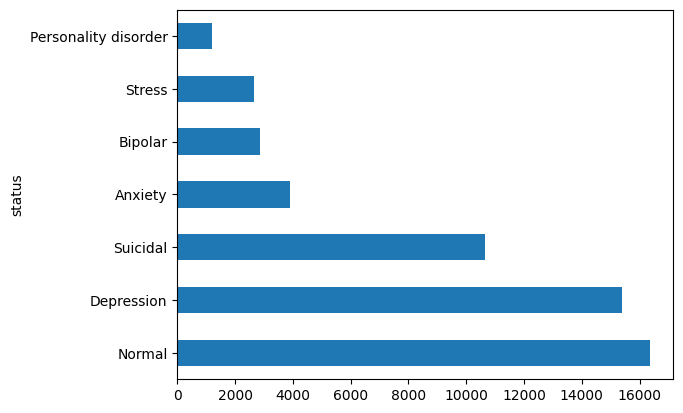

In [4]:
df["status"].value_counts().plot(kind="barh")

### text pre-precessing


In [5]:
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import nltk
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

- remove unwanted string like (!,#,$,%)
- convert to list for checking each word in stopword
- remove stopwords
- apply steamming or lemmatizer
- convert to vector


In [6]:
df = df.dropna()

In [7]:
port_stemmer = PorterStemmer()
lemma = WordNetLemmatizer()
# storing all pre-proccessed words in seprate list
corpus = []

In [8]:
for sen in range(len(df["statement"])):
    sentence = re.sub("[^a-zA-Z]", " ", df["statement"].iloc[sen]).lower().split()
    sentence = [
        lemma.lemmatize(word)
        for word in sentence
        if word not in stopwords.words("english")
    ]
    sentence = " ".join(sentence)
    corpus.append(sentence)
    if sen % 1000 == 0:
        print(sen)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000


In [9]:
len(corpus)

52681

### BOW (bag of words)


In [10]:
bow = CountVectorizer(max_features=150)
processed_text = bow.fit_transform(corpus).toarray()

In [11]:
processed_text[2]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [12]:
bow.vocabulary_

{'mind': np.int64(80),
 'back': np.int64(12),
 'something': np.int64(112),
 'else': np.int64(26),
 'still': np.int64(116),
 'month': np.int64(82),
 'every': np.int64(31),
 'like': np.int64(67),
 'feel': np.int64(35),
 'scared': np.int64(104),
 'family': np.int64(34),
 'ever': np.int64(30),
 'felt': np.int64(37),
 'know': np.int64(62),
 'well': np.int64(141),
 'day': np.int64(21),
 'really': np.int64(98),
 'want': np.int64(137),
 'cry': np.int64(20),
 'always': np.int64(5),
 'night': np.int64(87),
 'even': np.int64(29),
 'though': np.int64(126),
 'feeling': np.int64(36),
 'good': np.int64(47),
 'time': np.int64(128),
 'sleep': np.int64(110),
 'sometimes': np.int64(113),
 'problem': np.int64(97),
 'thought': np.int64(127),
 'make': np.int64(76),
 'going': np.int64(46),
 'try': np.int64(133),
 'hope': np.int64(56),
 'start': np.int64(114),
 'thing': np.int64(123),
 'much': np.int64(83),
 'actually': np.int64(1),
 'person': np.int64(95),
 'also': np.int64(4),
 'little': np.int64(68),
 'bes

In [13]:
bow.get_feature_names_out()

array(['able', 'actually', 'ago', 'alone', 'also', 'always', 'anxiety',
       'anymore', 'anyone', 'anything', 'around', 'away', 'back', 'bad',
       'best', 'better', 'cannot', 'care', 'come', 'could', 'cry', 'day',
       'depressed', 'depression', 'die', 'done', 'else', 'end', 'enough',
       'even', 'ever', 'every', 'everyone', 'everything', 'family',
       'feel', 'feeling', 'felt', 'find', 'first', 'friend', 'fucking',
       'get', 'getting', 'give', 'go', 'going', 'good', 'got', 'happy',
       'hard', 'hate', 'head', 'health', 'help', 'home', 'hope', 'hour',
       'hurt', 'job', 'keep', 'kill', 'know', 'last', 'left', 'let',
       'life', 'like', 'little', 'live', 'living', 'long', 'look', 'lot',
       'love', 'made', 'make', 'many', 'maybe', 'mental', 'mind', 'mom',
       'month', 'much', 'need', 'never', 'new', 'night', 'nothing', 'old',
       'one', 'pain', 'parent', 'past', 'people', 'person', 'point',
       'problem', 'really', 'reason', 'relationship', 'right',

### TF-IDF


In [14]:
tf_idf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))

In [15]:
X_tf = tf_idf.fit_transform(corpus).toarray()

In [16]:
X_tf.shape

(52681, 2000)

In [17]:
tf_idf.vocabulary_

{'oh': np.int64(1228),
 'trouble': np.int64(1806),
 'sleeping': np.int64(1569),
 'confused': np.int64(326),
 'mind': np.int64(1130),
 'restless': np.int64(1457),
 'heart': np.int64(794),
 'wrong': np.int64(1981),
 'back': np.int64(134),
 'forward': np.int64(655),
 'doubt': np.int64(457),
 'stay': np.int64(1629),
 'place': np.int64(1323),
 'focus': np.int64(641),
 'something': np.int64(1592),
 'else': np.int64(487),
 'still': np.int64(1634),
 'worried': np.int64(1956),
 'something else': np.int64(1593),
 'month': np.int64(1148),
 'boy': np.int64(197),
 'mean': np.int64(1096),
 'every': np.int64(528),
 'break': np.int64(202),
 'must': np.int64(1173),
 'nervous': np.int64(1189),
 'like': np.int64(984),
 'like something': np.int64(1001),
 'something wrong': np.int64(1595),
 'feel': np.int64(591),
 'scared': np.int64(1493),
 'anxious': np.int64(75),
 'may': np.int64(1093),
 'family': np.int64(580),
 'ever': np.int64(525),
 'felt': np.int64(610),
 'know': np.int64(915),
 'slept': np.int64(15

In [18]:
tf_idf.get_feature_names_out()

array(['ability', 'able', 'able get', ..., 'yr', 'zero', 'zoloft'],
      shape=(2000,), dtype=object)

In [21]:
joblib.dump(tf_idf, "models/tf_idf.pkl")

['models/tf_idf.pkl']

### model training with different algorithm


In [22]:
label_encoding = LabelEncoder()
y = label_encoding.fit_transform(df[["status"]])
label_encoding.classes_

d:\Old PycharmProjects\ML python\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array(['Anxiety', 'Bipolar', 'Depression', 'Normal',
       'Personality disorder', 'Stress', 'Suicidal'], dtype=object)

In [23]:
joblib.dump(label_encoding, "models/label_encoder_for_target.pkl")

['models/label_encoder_for_target.pkl']

#### balancing dataset


In [31]:
from imblearn.over_sampling import RandomOverSampler

over_sampling = RandomOverSampler()
X_resampled, y_resampled = over_sampling.fit_resample(X_tf, y)
X_resampled.shape
y.shape

(52681,)

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.20, random_state=36
)

In [ ]:
model = {
    "random_forest": RandomForestClassifier(),
    "logistic_regession": LogisticRegression(),
    # "SVC": SVC(),
    # "gradient":GradientBoostingClassifier(n_jobs=-1),
    # "ada_boost":AdaBoostClassifier(n_jobs=-1),
    # "decision_tree":DecisionTreeClassifier(n_jobs=-1),
}
for n_model in range(len(model)):
    c_model = list(model.values())[n_model]
    c_model.fit(X_train, y_train)

    y_pred = c_model.predict(X_test)

    print("===========================================")
    print(list(model.keys())[n_model])
    print("Model performance for testing set")
    print(classification_report(y_test, y_pred, target_names=label_encoding.classes_))
    print("=============================================")

: 

In [35]:
model["logistic_regession"].score(X_resampled, y_resampled)

0.8265050130680676

In [36]:
joblib.dump(model["logistic_regession"], "models/logistic_regression_model.pkl")

['models/logistic_regression_model.pkl']

In [37]:
model["random_forest"].score(X_resampled, y_resampled)

0.9818445642957666

In [38]:
joblib.dump(model["random_forest"], "models/random_forest.pkl")

['models/random_forest.pkl']

### owning sentence ouput


In [18]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import joblib
import warnings
warnings.filterwarnings("ignore")

lemma = WordNetLemmatizer()

test_st = input("Enter your text: ")

test_corpus = []

sentence = re.sub("[^a-zA-Z]", " ", test_st).lower().split()
# print(sentence)
sentence = [
    lemma.lemmatize(word) for word in sentence if word not in stopwords.words("english")
]
# print(sentence)

sentence = " ".join(word for word in sentence if word != " ")
test_corpus.append(sentence)
test_corpus

['bf month already told depressed week nothing particular happened feel he bothered ask sleep together thing etci know problem aware wanted ask without suffocating really clingy thing usually love right kind feeling much suggestion gladly accepted frank tell make worse bother bf bad time due depression']

### loading tf-idf, label and random forest model to predict new data


In [19]:
tf_idf_model = joblib.load("models/tf_idf.pkl")
test_y = tf_idf_model.transform(test_corpus).toarray()

In [20]:
random_model_loaded = joblib.load("models/logistic_regression_model.pkl")
test_y_pred = random_model_loaded.predict(test_y)

In [21]:
label_encoding_loaded = joblib.load("models/label_encoder_for_target.pkl")
label_encoding_loaded.inverse_transform(test_y_pred)[0]

'Depression'

## depression

So I have been with my bf for 5 months , and he already told me he was depressed. To this week nothing particular happened, but i can now feel hes bothered by it. He does not ask me to sleep together, do things and etcI know I am not the problem I am aware of that, I just wanted to ask: how can I be there without suffocating him? I am really clingy, a thing which he usually loves about me but right now I kind of have a feeling that I am doing too much.Any suggestion will be gladly accepted, be frank and tell me how I can not make it worse: its that that bothers me. My bf (21) is having a bad time due to his depression


In [ ]:
df[df["status"] == "Anxiety"]

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [ ]:
df["status"].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [ ]:
df.iloc[6982][1]

/tmp/ipykernel_5948/2539318651.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[6982][1]


'Been stuck in a loop of ruminating/ overthinking. I still cannot seem to connect with another person I find attractive even though that is the least of my problems right now. Just overwhelmed with what is in front of me and trying to stay calm but imposter syndrome is ringing in my ears Low'

### saving the models


In [ ]:
joblib.dump(model["random_forest"], "random_forest.pkl")

['random_forest.pkl']